In [57]:
# %pip install emoji

In [58]:
# %pip install spacy && python -m spacy download es_core_news_sm

## EDA

In this notebook we explore the train_aggressiveness.csv dataset to understand its characteristics before training ML models to predict the category of the text (0 for no aggressive and 1 otherwise).

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

pd.set_option("display.max_colwidth", None)

In [60]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
file_path = "/content/drive/MyDrive/data_colab/MEX-A3T/train_aggressiveness.csv"
df = pd.read_csv(file_path)
df = df.drop("Id", axis=1)
display(df.head())

,Category,Text
0,0,Soy el Clint Eastwood de los Puentes de Madison en todas las putas historias de amor que me han tocado.\n
1,0,"Actualmente ya pasó de moda la pucha joto, ahora sólo quedamos los verdaderos seguidores, los que amamos este estilo de vida.\n"
2,0,"¿Es cierto esto? Y no me refiero a lo que dijo, ni al tweet, sino a👉<URL>¿Están tratando de sacarlo del programa?\n"
3,0,Vuela pega y esquiva... la neta está de la vergaaaa pero es pegajosa!!\n
4,0,Mejor puto disfraz de la noche!!!! 👊👊👊Por tercer año consecutivo morros\n


### Distribution of the Category column (target)

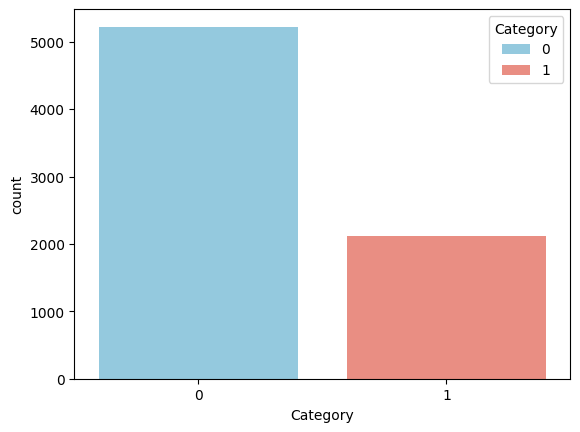

In [62]:
sns.countplot(x="Category", data=df, hue="Category", palette=["skyblue", "salmon"]);

In [ ]:
# Calculate and display percentages for each category
category_counts = df["Category"].value_counts().sort_index()
category_percentages = (
    df["Category"].value_counts(normalize=True).sort_index() * 100
).round(2)

percentage_df = pd.DataFrame(
    {
        "Category": ["Non-Aggressive (0)", "Aggressive (1)"],
        "Count": category_counts.values,
        "Percentage": category_percentages.values,
    }
)

print("Category Distribution:")
display(percentage_df)

print(f"\nSummary:")
print(f"Total tweets: {len(df)}")
print(f"Non-Aggressive: {category_counts[0]} tweets ({category_percentages[0]}%)")
print(f"Aggressive: {category_counts[1]} tweets ({category_percentages[1]}%)")

### Lenght of the Tweets text

In [63]:
df["length"] = df.Text.str.len()
df["word_count"] = df["Text"].str.split().str.len()

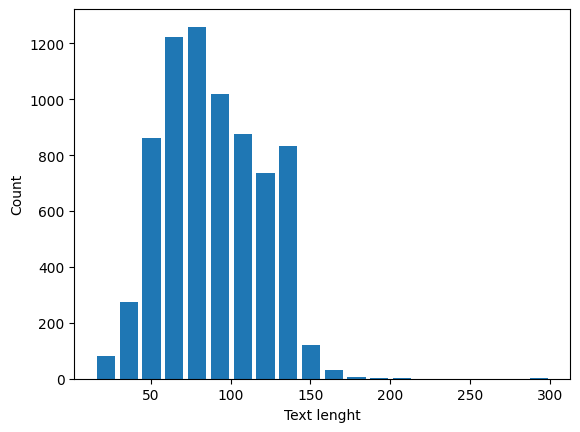

In [64]:
plt.hist(df.length, bins=20, rwidth=0.8)
plt.xlabel("Text lenght")
plt.ylabel("Count");

In [65]:
df[df.length > 200]

,Category,Text,length,word_count
1711,1,"@USUARIO @USUARIO Callate el hocico puta, ya quisieras ser mexicana Puta panameña de mierda tu pais es un asco igual que las personas que viven ahi puro puto negro de mierda que asco y luego son bien putos llorones ojala el bolillo se muera junto con toda la puta seleccion panameña aquerosa alv!!!\n",300,53
2718,1,Es si no sabia que habían dado mas caracteres para metar le la madre la madre a peña nieto peña chingas a tu madre chingas a tu madre a y tambien Alejandro murat igual que chingev a su madre mas de mil veces\n,208,43
3422,1,Ahora recuerdo por que no iba al cine en dias cercanos a la quincena... es cuando los nacos y la gente nefasta tiene para ir!! Que puto asco @USUARIO que sigas dejando entrar a menores a funciones B15\n,201,38
4334,1,"Putos los que no fueron a ayudar en el temblor, al chile yo si fui a remover los escombros a la condesa y hasta una pinche laptop y un Iphone me encontre y mi carnalito el Jonathan se trajo una pantalla.\n",204,41


### Difference in length of aggressiveness and no aggressiveness tweets

In [66]:
aggressive = df[df.Category == 1]
no_aggressive = df[df.Category == 0]

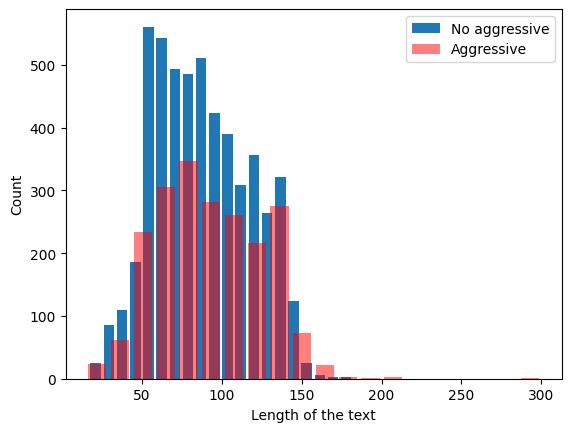

In [67]:
plt.hist(no_aggressive.length, bins=20, rwidth=0.8, label="No aggressive")
plt.hist(
    aggressive.length, bins=20, rwidth=0.8, label="Aggressive", alpha=0.5, color="red"
)
plt.xlabel("Length of the text")
plt.ylabel("Count")
plt.legend(loc="upper right");

## Word count

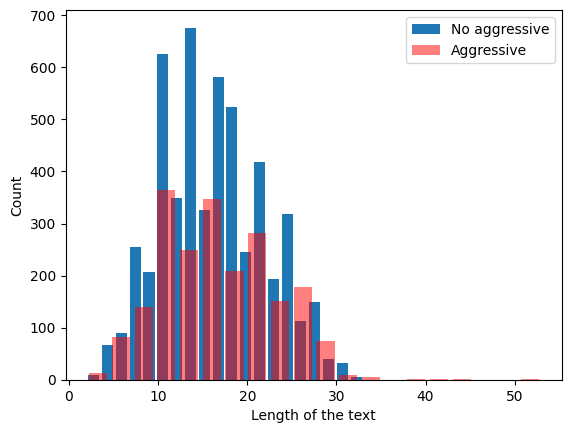

In [68]:
plt.hist(no_aggressive.word_count, bins=20, rwidth=0.8, label="No aggressive")
plt.hist(
    aggressive.word_count,
    bins=20,
    rwidth=0.8,
    label="Aggressive",
    alpha=0.5,
    color="red",
)
plt.xlabel("Length of the text")
plt.ylabel("Count")
plt.legend(loc="upper right");

## Top N Most Frequent Words (per class, before cleaning)

In [73]:
from collections import Counter

# Top words in non-aggressive tweets
no_agg_words = Counter()
for text in no_aggressive.Text:
    no_agg_words.update(text.split())

# Top words in aggressive tweets
agg_words = Counter()
for text in aggressive.Text:
    agg_words.update(text.split())

# Create side-by-side DataFrame
top_n = 30
no_agg_df = pd.DataFrame(
    no_agg_words.most_common(top_n), columns=["Word", "Count (Non-Aggressive)"]
)
agg_df = pd.DataFrame(
    agg_words.most_common(top_n), columns=["Word", "Count (Aggressive)"]
)

comparison_df = pd.concat(
    [no_agg_df.reset_index(drop=True), agg_df.reset_index(drop=True)], axis=1
)
display(comparison_df)

,Word,Count (Non-Aggressive),Word,Count (Aggressive)
0,que,2842,de,1268
1,de,2767,que,1047
2,la,2129,a,964
3,y,1826,@USUARIO,931
4,a,1792,y,747
5,me,1448,la,737
6,no,1308,no,537
7,en,1145,el,463
8,el,1022,se,370
9,@USUARIO,973,los,370


## Spanish Stop Word Analysis

In [74]:
import spacy

nlp = spacy.load("es_core_news_sm")
spanish_stopwords = nlp.Defaults.stop_words


# Count stop words vs non-stop words per class
def analyze_stopwords(texts, stopwords_set):
    total_tokens = 0
    stop_token_count = 0
    stop_word_counter = Counter()
    non_stop_word_counter = Counter()

    for text in texts:
        tokens = text.lower().split()
        total_tokens += len(tokens)
        for token in tokens:
            if token in stopwords_set:
                stop_token_count += 1
                stop_word_counter[token] += 1
            else:
                non_stop_word_counter[token] += 1

    stop_word_pct = (stop_token_count / total_tokens * 100) if total_tokens > 0 else 0
    return stop_word_pct, stop_word_counter, non_stop_word_counter


no_agg_stop_pct, no_agg_stops, no_agg_signals = analyze_stopwords(
    no_aggressive.Text, spanish_stopwords
)
agg_stop_pct, agg_stops, agg_signals = analyze_stopwords(
    aggressive.Text, spanish_stopwords
)

print(f"Non-Aggressive tweets: {no_agg_stop_pct:.2f}% are stop words")
print(f"Aggressive tweets: {agg_stop_pct:.2f}% are stop words")
print("\nTop 20 stop words (across all tweets):")
all_stops = no_agg_stops + agg_stops
stop_df = pd.DataFrame(all_stops.most_common(20), columns=["Stop Word", "Count"])
display(stop_df)

print("\nTop 20 signal words (non-stop) - Non-Aggressive:")
no_agg_signal_df = pd.DataFrame(
    no_agg_signals.most_common(20), columns=["Word", "Count"]
)
display(no_agg_signal_df)

print("\nTop 20 signal words (non-stop) - Aggressive:")
agg_signal_df = pd.DataFrame(agg_signals.most_common(20), columns=["Word", "Count"])
display(agg_signal_df)

Non-Aggressive tweets: 52.32% are stop words
Aggressive tweets: 49.37% are stop words

Top 20 stop words (across all tweets):


,Stop Word,Count
0,que,4280
1,de,4261
2,la,3162
3,a,3077
4,y,2881
5,no,2342
6,me,2046
7,el,1661
8,en,1589
9,se,1294



Top 20 signal words (non-stop) - Non-Aggressive:


,Word,Count
0,@usuario,973
1,verga,600
2,madre,498
3,putas,467
4,loca,355
5,putos,292
6,gorda,228
7,feas,173
8,quiero,164
9,cosas,154



Top 20 signal words (non-stop) - Aggressive:


,Word,Count
0,@usuario,931
1,putos,358
2,madre,264
3,pinche,232
4,putas,194
5,verga,168
6,puta,153
7,hdp,125
8,pinches,112
9,puto,103


## Emoji Frequency Analysis

In [75]:
import emoji


def analyze_emojis(texts):
    emoji_counter = Counter()
    tweets_with_emoji = 0

    for text in texts:
        emojis_in_text = emoji.emoji_list(text)
        if emojis_in_text:
            tweets_with_emoji += 1
            for emoji_dict in emojis_in_text:
                emoji_char = emoji_dict["emoji"]
                emoji_counter[emoji_char] += 1

    emoji_pct = (tweets_with_emoji / len(texts) * 100) if len(texts) > 0 else 0
    return emoji_pct, emoji_counter


no_agg_emoji_pct, no_agg_emojis = analyze_emojis(no_aggressive.Text)
agg_emoji_pct, agg_emojis = analyze_emojis(aggressive.Text)

print(f"Non-Aggressive tweets with emoji: {no_agg_emoji_pct:.2f}%")
print(f"Aggressive tweets with emoji: {agg_emoji_pct:.2f}%")

print("\nTop 15 emojis - Non-Aggressive:")
no_agg_emoji_df = pd.DataFrame(
    no_agg_emojis.most_common(15), columns=["Emoji", "Count"]
)
display(no_agg_emoji_df)

print("\nTop 15 emojis - Aggressive:")
agg_emoji_df = pd.DataFrame(agg_emojis.most_common(15), columns=["Emoji", "Count"])
display(agg_emoji_df)

Non-Aggressive tweets with emoji: 25.34%
Aggressive tweets with emoji: 16.45%

Top 15 emojis - Non-Aggressive:


,Emoji,Count
0,😂,498
1,😭,169
2,😡,137
3,😍,119
4,🙄,75
5,😱,58
6,🤔,58
7,😩,50
8,❤,49
9,😈,48



Top 15 emojis - Aggressive:


,Emoji,Count
0,😂,238
1,😡,36
2,🙄,31
3,🤣,30
4,😠,24
5,😒,23
6,😭,19
7,😤,16
8,🎶,16
9,🤔,14


## Special Token Analysis (`<URL>`, `@USUARIO`, `\n`)

In [82]:
def analyze_special_tokens(df_group, tokens_to_check=["<URL>", "@USUARIO", "\n"]):
    results = {}

    for token in tokens_to_check:
        tweets_with_token = (df_group.Text.str.contains(token)).sum()
        pct_with_token = (
            (tweets_with_token / len(df_group) * 100) if len(df_group) > 0 else 0
        )

        total_occurrences = df_group.Text.str.count(token).sum()
        mean_per_tweet = df_group.Text.str.count(token).mean()

        results[token] = {
            "Tweets with token (%)": f"{pct_with_token:.2f}%",
            "Total occurrences": total_occurrences,
            "Mean per tweet": f"{mean_per_tweet:.3f}",
        }

    return results


no_agg_tokens = analyze_special_tokens(no_aggressive)
agg_tokens = analyze_special_tokens(aggressive)

# Create comparison table
tokens_list = ["<URL>", "@USUARIO", "\n"]
comparison_data = []
for token in tokens_list:
    comparison_data.append(
        {
            "Token": token,
            "Non-Agg (%)": no_agg_tokens[token]["Tweets with token (%)"],
            "Non-Agg Total": no_agg_tokens[token]["Total occurrences"],
            "Non-Agg Mean": no_agg_tokens[token]["Mean per tweet"],
            "Agg (%)": agg_tokens[token]["Tweets with token (%)"],
            "Agg Total": agg_tokens[token]["Total occurrences"],
            "Agg Mean": agg_tokens[token]["Mean per tweet"],
        }
    )

tokens_df = pd.DataFrame(comparison_data)
display(tokens_df)

,Token,Non-Agg (%),Non-Agg Total,Non-Agg Mean,Agg (%),Agg Total,Agg Mean
0,<URL>,2.62%,137,0.026,1.71%,36,0.017
1,@USUARIO,14.15%,990,0.190,28.58%,941,0.446
2,\n,100.00%,5222,1.000,100.00%,2110,1.000


## Spanish-Specific Character Distribution

In [78]:
import re
import unicodedata


def count_accented_chars(texts):
    # Spanish accented characters
    accented_vowels = {
        "á": "a",
        "é": "e",
        "í": "i",
        "ó": "o",
        "ú": "u",
        "Á": "A",
        "É": "E",
        "Í": "I",
        "Ó": "O",
        "Ú": "U",
    }
    special_chars = {"ñ": "n", "Ñ": "N", "ü": "u", "Ü": "U"}

    char_counts = {}
    all_chars = {**accented_vowels, **special_chars}

    for char in all_chars:
        char_counts[char] = 0

    total_text = "".join(texts)
    for char in all_chars:
        char_counts[char] = total_text.count(char)

    return char_counts


no_agg_accents = count_accented_chars(no_aggressive.Text)
agg_accents = count_accented_chars(aggressive.Text)

# Create comparison table
accent_data = []
for char in list(no_agg_accents.keys())[:10]:  # Show first 10
    accent_data.append(
        {
            "Character": char,
            "Non-Agg Count": no_agg_accents[char],
            "Agg Count": agg_accents[char],
        }
    )

accents_df = pd.DataFrame(accent_data)
display(accents_df)

# Calculate total vowels with accents vs without
total_no_agg_text = "".join(no_aggressive.Text)
total_agg_text = "".join(aggressive.Text)

accented_vowel_count_no_agg = sum(
    total_no_agg_text.count(v)
    for v in ["á", "é", "í", "ó", "ú", "Á", "É", "Í", "Ó", "Ú"]
)
accented_vowel_count_agg = sum(
    total_agg_text.count(v) for v in ["á", "é", "í", "ó", "ú", "Á", "É", "Í", "Ó", "Ú"]
)

print(f"\nTotal accented vowels - Non-Aggressive: {accented_vowel_count_no_agg}")
print(f"Total accented vowels - Aggressive: {accented_vowel_count_agg}")

,Character,Non-Agg Count,Agg Count
0,á,1387,514
1,é,1068,344
2,í,1414,460
3,ó,978,386
4,ú,324,135
5,Á,29,23
6,É,37,29
7,Í,21,18
8,Ó,37,16
9,Ú,8,7



Total accented vowels - Non-Aggressive: 5303
Total accented vowels - Aggressive: 1932


## Punctuation and Special Character Distribution

/tmp/ipykernel_2329/3259210971.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_aggressive['punct_count'] = no_aggressive.Text.apply(count_punctuation)
/tmp/ipykernel_2329/3259210971.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aggressive['punct_count'] = aggressive.Text.apply(count_punctuation)
/tmp/ipykernel_2329/3259210971.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3

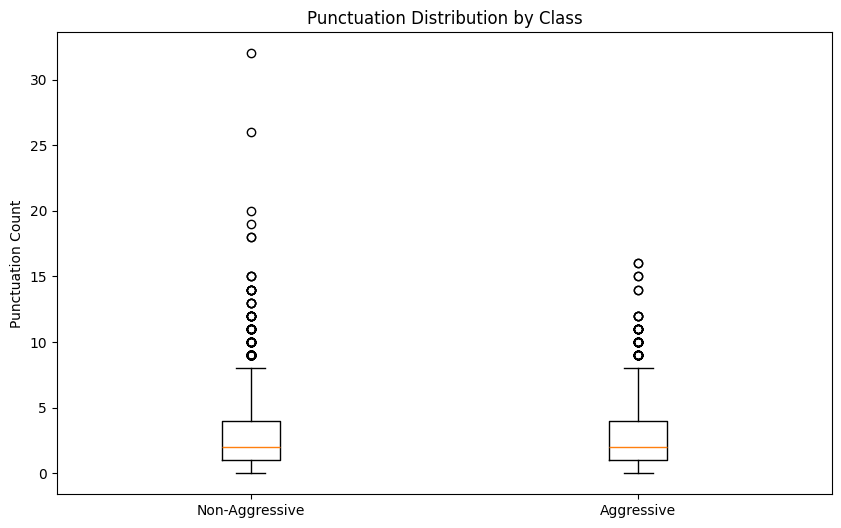

Non-Aggressive - Mean punctuation: 2.65
Aggressive - Mean punctuation: 2.81

Top 10 punctuation/special chars - Non-Aggressive:


,Char,Count
0,.,4220
1,",",2942
2,!,1356
3,@,1014
4,#,939
5,?,709
6,"""",671
7,:,369
8,¿,285
9,-,169



Top 10 punctuation/special chars - Aggressive:


,Char,Count
0,.,1701
1,",",1304
2,@,965
3,!,777
4,?,307
5,#,270
6,"""",141
7,:,74
8,¿,59
9,¡,44


In [79]:
import string


# Count punctuation per tweet
def count_punctuation(text):
    punct_set = set(string.punctuation + "¡¿")
    return sum(1 for char in text if char in punct_set)


no_aggressive["punct_count"] = no_aggressive.Text.apply(count_punctuation)
aggressive["punct_count"] = aggressive.Text.apply(count_punctuation)

# Plot boxplot comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
data_to_plot = [no_aggressive["punct_count"], aggressive["punct_count"]]
ax.boxplot(data_to_plot, labels=["Non-Aggressive", "Aggressive"])
ax.set_ylabel("Punctuation Count")
ax.set_title("Punctuation Distribution by Class")
plt.show()

print(f"Non-Aggressive - Mean punctuation: {no_aggressive['punct_count'].mean():.2f}")
print(f"Aggressive - Mean punctuation: {aggressive['punct_count'].mean():.2f}")


# Top punctuation/special characters per class
def get_top_punctuation(texts):
    punct_set = set(string.punctuation + "¡¿—–«»")
    punct_counter = Counter()

    total_text = "".join(texts)
    for char in punct_set:
        count = total_text.count(char)
        if count > 0:
            punct_counter[char] = count

    return punct_counter


no_agg_punct = get_top_punctuation(no_aggressive.Text)
agg_punct = get_top_punctuation(aggressive.Text)

print("\nTop 10 punctuation/special chars - Non-Aggressive:")
no_agg_punct_df = pd.DataFrame(no_agg_punct.most_common(10), columns=["Char", "Count"])
display(no_agg_punct_df)

print("\nTop 10 punctuation/special chars - Aggressive:")
agg_punct_df = pd.DataFrame(agg_punct.most_common(10), columns=["Char", "Count"])
display(agg_punct_df)

## Bigram and Trigram Frequency (after light cleaning)

In [80]:
from sklearn.feature_extraction.text import CountVectorizer


# Light cleaning: lowercase, remove <URL>, @USUARIO, \n
def light_clean(text):
    text = text.lower()
    text = text.replace("<url>", "")
    text = text.replace("@usuario", "")
    text = text.replace("\n", "")
    return text


no_agg_cleaned = no_aggressive.Text.apply(light_clean)
agg_cleaned = aggressive.Text.apply(light_clean)

# Extract bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=100)
no_agg_bigrams = bigram_vectorizer.fit_transform(no_agg_cleaned)
agg_bigrams = bigram_vectorizer.fit_transform(agg_cleaned)

# Get top bigrams for non-aggressive
no_agg_bigram_names = bigram_vectorizer.get_feature_names_out()
no_agg_bigram_counts = no_agg_bigrams.sum(axis=0).A1
no_agg_bigram_df = pd.DataFrame(
    {
        "Bigram": no_agg_bigram_names[np.argsort(-no_agg_bigram_counts)[:20]],
        "Count": np.sort(-no_agg_bigram_counts)[:20],
    }
)
no_agg_bigram_df["Count"] = -no_agg_bigram_df["Count"]

print("Top 20 Bigrams - Non-Aggressive:")
display(no_agg_bigram_df.reset_index(drop=True))

# Get top bigrams for aggressive
agg_bigram_names = bigram_vectorizer.get_feature_names_out()
agg_bigram_counts = agg_bigrams.sum(axis=0).A1
agg_bigram_df = pd.DataFrame(
    {
        "Bigram": agg_bigram_names[np.argsort(-agg_bigram_counts)[:20]],
        "Count": np.sort(-agg_bigram_counts)[:20],
    }
)
agg_bigram_df["Count"] = -agg_bigram_df["Count"]

print("\nTop 20 Bigrams - Aggressive:")
display(agg_bigram_df.reset_index(drop=True))

# Extract trigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), max_features=100)
no_agg_trigrams = trigram_vectorizer.fit_transform(no_agg_cleaned)
agg_trigrams = trigram_vectorizer.fit_transform(agg_cleaned)

# Get top trigrams for non-aggressive
no_agg_trigram_names = trigram_vectorizer.get_feature_names_out()
no_agg_trigram_counts = no_agg_trigrams.sum(axis=0).A1
no_agg_trigram_df = pd.DataFrame(
    {
        "Trigram": no_agg_trigram_names[np.argsort(-no_agg_trigram_counts)[:20]],
        "Count": np.sort(-no_agg_trigram_counts)[:20],
    }
)
no_agg_trigram_df["Count"] = -no_agg_trigram_df["Count"]

print("\nTop 20 Trigrams - Non-Aggressive:")
display(no_agg_trigram_df.reset_index(drop=True))

# Get top trigrams for aggressive
agg_trigram_names = trigram_vectorizer.get_feature_names_out()
agg_trigram_counts = agg_trigrams.sum(axis=0).A1
agg_trigram_df = pd.DataFrame(
    {
        "Trigram": agg_trigram_names[np.argsort(-agg_trigram_counts)[:20]],
        "Count": np.sort(-agg_trigram_counts)[:20],
    }
)
agg_trigram_df["Count"] = -agg_trigram_df["Count"]

print("\nTop 20 Trigrams - Aggressive:")
display(agg_trigram_df.reset_index(drop=True))

Top 20 Bigrams - Non-Aggressive:


,Bigram,Count
0,chinguen su,315
1,es un,293
2,que es,240
3,que la,205
4,de putas,169
5,es que,158
6,de puta,146
7,que le,136
8,hija de,133
9,no mamen,129



Top 20 Bigrams - Aggressive:


,Bigram,Count
0,la verga,121
1,de la,94
2,los putos,90
3,que no,87
4,tu madre,81
5,hijo de,78
6,puta madre,77
7,su madre,74
8,de mierda,73
9,que se,71



Top 20 Trigrams - Non-Aggressive:


,Trigram,Count
0,de la chingada,76
1,par de putos,37
2,hijo de perra,36
3,hijo de mil,28
4,no les gusta,27
5,tu madre tu,26
6,hija de tu,22
7,deja de mamar,19
8,las putas de,19
9,de la verga,19



Top 20 Trigrams - Aggressive:


,Trigram,Count
0,tu puta madre,39
1,chinguen su madre,29
2,chingas tu madre,29
3,de tu puta,28
4,hijo de tu,28
5,su puta madre,27
6,chinga tu madre,26
7,hijos de su,23
8,chingar su madre,22
9,de su puta,21


## Summary Statistics Table: Preprocessing Guide

In [81]:
# Consolidate all summary statistics into one table
summary_data = {
    "Metric": [
        "Tweet Count",
        "Avg Character Length",
        "Avg Word Count",
        "Tweets with Emoji (%)",
        "Tweets with <URL> (%)",
        "Tweets with @USUARIO (%)",
        "Tweets with Newline (%)",
        "Avg Punctuation Count",
        "Stop Words (%)",
        "Accented Vowels (Total)",
    ],
    "Non-Aggressive": [
        len(no_aggressive),
        f"{no_aggressive.length.mean():.2f}",
        f"{no_aggressive.word_count.mean():.2f}",
        f"{no_agg_emoji_pct:.2f}",
        f"{float(no_agg_tokens['<URL>']['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{float(no_agg_tokens['@USUARIO']['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{float(no_agg_tokens[chr(10)]['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{no_aggressive.punct_count.mean():.2f}",
        f"{no_agg_stop_pct:.2f}",
        accented_vowel_count_no_agg,
    ],
    "Aggressive": [
        len(aggressive),
        f"{aggressive.length.mean():.2f}",
        f"{aggressive.word_count.mean():.2f}",
        f"{agg_emoji_pct:.2f}",
        f"{float(agg_tokens['<URL>']['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{float(agg_tokens['@USUARIO']['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{float(agg_tokens[chr(10)]['Tweets with token (%)'].rstrip('%')):.2f}",
        f"{aggressive.punct_count.mean():.2f}",
        f"{agg_stop_pct:.2f}",
        accented_vowel_count_agg,
    ],
}

summary_df = pd.DataFrame(summary_data)
print("EDA Summary Statistics - Preprocessing Guide\n")
display(summary_df.style.format({"Non-Aggressive": "{}", "Aggressive": "{}"}))

print("\n" + "=" * 80)
print("KEY INSIGHTS FOR TEXT PREPROCESSING:")
print("=" * 80)
print("\n1. EMOJI HANDLING:")
print(
    f"   - Both classes contain emojis (Non-Agg: {no_agg_emoji_pct:.1f}%, Agg: {agg_emoji_pct:.1f}%)"
)
print(f"   - Consider: Removing vs. encoding as special tokens")

print("\n2. SPECIAL TOKENS (<URL>, @USUARIO, \\n):")
print(f"   - These placeholder tokens are common and may not add signal")
print(f"   - Recommendation: Remove all three for cleaner feature space")

print("\n3. STOP WORDS:")
print(f"   - Non-Agg tweets: {no_agg_stop_pct:.1f}% stop words")
print(f"   - Agg tweets: {agg_stop_pct:.1f}% stop words")
print(f"   - Recommendation: Remove Spanish stop words to focus on signal")

print("\n4. ACCENTS & DIACRITICS:")
print(
    f"   - Corpus contains {accented_vowel_count_no_agg + accented_vowel_count_agg} accented vowels total"
)
print(f"   - Recommendation: Keep accents (they carry meaning in Spanish)")
print(f"     OR normalize with unidecode if model handles ASCII better")

print("\n5. PUNCTUATION:")
print(
    f"   - Aggressive tweets: {aggressive.punct_count.mean():.2f} avg punctuation chars"
)
print(
    f"   - Non-Agg tweets: {no_aggressive.punct_count.mean():.2f} avg punctuation chars"
)
print(f"   - Observation: Aggressive tweets tend to have MORE punctuation")
print(f"   - Recommendation: Keep punctuation; it correlates with aggression")

print("\n6. N-GRAMS:")
print(f"   - Bigrams and trigrams show class-specific patterns")
print(f"   - Recommendation: Use ngram_range=(1,2) or (1,3) in TF-IDF")

print("\n" + "=" * 80)

EDA Summary Statistics - Preprocessing Guide



,Metric,Non-Aggressive,Aggressive
0,Tweet Count,5222,2110
1,Avg Character Length,87.38,93.17
2,Avg Word Count,16.11,16.78
3,Tweets with Emoji (%),25.34,16.45
4,Tweets with (%),2.62,1.71
5,Tweets with @USUARIO (%),14.15,28.58
6,Tweets with Newline (%),100.00,100.00
7,Avg Punctuation Count,2.65,2.81
8,Stop Words (%),52.32,49.37
9,Accented Vowels (Total),5303,1932



KEY INSIGHTS FOR TEXT PREPROCESSING:

1. EMOJI HANDLING:
   - Both classes contain emojis (Non-Agg: 25.3%, Agg: 16.4%)
   - Consider: Removing vs. encoding as special tokens

2. SPECIAL TOKENS (<URL>, @USUARIO, \n):
   - These placeholder tokens are common and may not add signal
   - Recommendation: Remove all three for cleaner feature space

3. STOP WORDS:
   - Non-Agg tweets: 52.3% stop words
   - Agg tweets: 49.4% stop words
   - Recommendation: Remove Spanish stop words to focus on signal

4. ACCENTS & DIACRITICS:
   - Corpus contains 7235 accented vowels total
   - Recommendation: Keep accents (they carry meaning in Spanish)
     OR normalize with unidecode if model handles ASCII better

5. PUNCTUATION:
   - Aggressive tweets: 2.81 avg punctuation chars
   - Non-Agg tweets: 2.65 avg punctuation chars
   - Observation: Aggressive tweets tend to have MORE punctuation
   - Recommendation: Keep punctuation; it correlates with aggression

6. N-GRAMS:
   - Bigrams and trigrams show cla

## Extra analysis

In [83]:
def discover_special_tokens(df, text_column="Text", min_frequency=10):
    """
    Automatically discover special tokens/placeholders in text data.

    Returns a dict of discovered patterns with their frequencies.
    """
    all_text = " ".join(df[text_column].astype(str))
    discovered = {}

    # 1. Angle-bracketed tokens: <WORD>
    angle_pattern = r"<([A-Z_]+)>"
    matches = re.findall(angle_pattern, all_text)
    for match in set(matches):
        freq = matches.count(match)
        if freq >= min_frequency:
            discovered[f"<{match}>"] = freq

    # 2. @ mention patterns
    mention_pattern = r"@\w+"
    mention_matches = re.findall(mention_pattern, all_text)
    mention_counts = Counter(mention_matches)
    for mention, freq in mention_counts.most_common(5):
        if freq >= min_frequency:
            discovered[mention] = freq

    # 3. Common escape sequences
    escape_sequences = {
        "\\n": all_text.count("\\n"),
        "\\t": all_text.count("\\t"),
        "\\r": all_text.count("\\r"),
    }
    for seq, count in escape_sequences.items():
        if count >= min_frequency:
            discovered[seq] = count

    # 4. URLs (if not yet replaced)
    url_pattern = r"http\S+|www\.\S+"
    url_matches = re.findall(url_pattern, all_text)
    if url_matches:
        discovered["URLs (unreplaced)"] = len(url_matches)

    return discovered


# Usage
tokens_found = discover_special_tokens(df)
for token, freq in sorted(tokens_found.items(), key=lambda x: x[1], reverse=True):
    print(f"{token}: {freq} occurrences")

@USUARIO: 1930 occurrences
<URL>: 173 occurrences
URLs (unreplaced): 2 occurrences
